# Тест модуля ModelDiagnostics

Проверка работы `ModelDiagnostics` на синтетических данных (регрессия и классификация).

## Импорты и путь к модулю

In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\grchi\AppData\Local\Programs\Python\Python312\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\grchi\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression, make_classification
from catboost import CatBoostClassifier, CatBoostRegressor

from src.modeldiagnostics import ModelDiagnostics

c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Регрессия

In [3]:
X_reg, y_reg = make_regression(n_samples=1500, n_features=10, n_informative=6, noise=15.0, random_state=42)
cols = [f"f{i}" for i in range(X_reg.shape[1])]
X_reg = pd.DataFrame(X_reg, columns=cols)
y_reg = pd.Series(y_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

model_reg = CatBoostRegressor(iterations=100, random_seed=42, verbose=0)
model_reg.fit(X_train_r, y_train_r)

md_reg = ModelDiagnostics(
    X_train_r, y_train_r, X_test_r, y_test_r,
    model_reg, task_type="regression"
)

Failed to read module file 'c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\src\modeldiagnostics.py' for module 'src.modeldiagnostics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\grchi\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1251.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x98 in position 958: character maps to <undefined>


In [4]:
metrics_train_r, metrics_test_r = md_reg.compute_metrics(print_metrics=True)

mse_train: 108.54044899422209
mse_test: 663.3914897002657
--------------------------------------------------
rmse_train: 10.41827476092957
rmse_test: 25.75638735731907
--------------------------------------------------
mae_train: 8.262584738448949
mae_test: 18.591280612247083
--------------------------------------------------
mape_train: 1.2281564831867562
mape_test: 0.805979312137703
--------------------------------------------------
r2_train: 0.9947367983339899
r2_test: 0.9653456352802616
--------------------------------------------------
max_error_train: 42.52946779241179
max_error_test: 171.69169684605242
--------------------------------------------------
bias_train: -0.0015398435249847151
bias_test: 1.8726342284992887
--------------------------------------------------
median_error_train: 0.12427604248973978
median_error_test: 1.4332162009357603
--------------------------------------------------
mpe_train: -0.4565844334780223
mpe_test: 0.07800237374967009
--------------------------

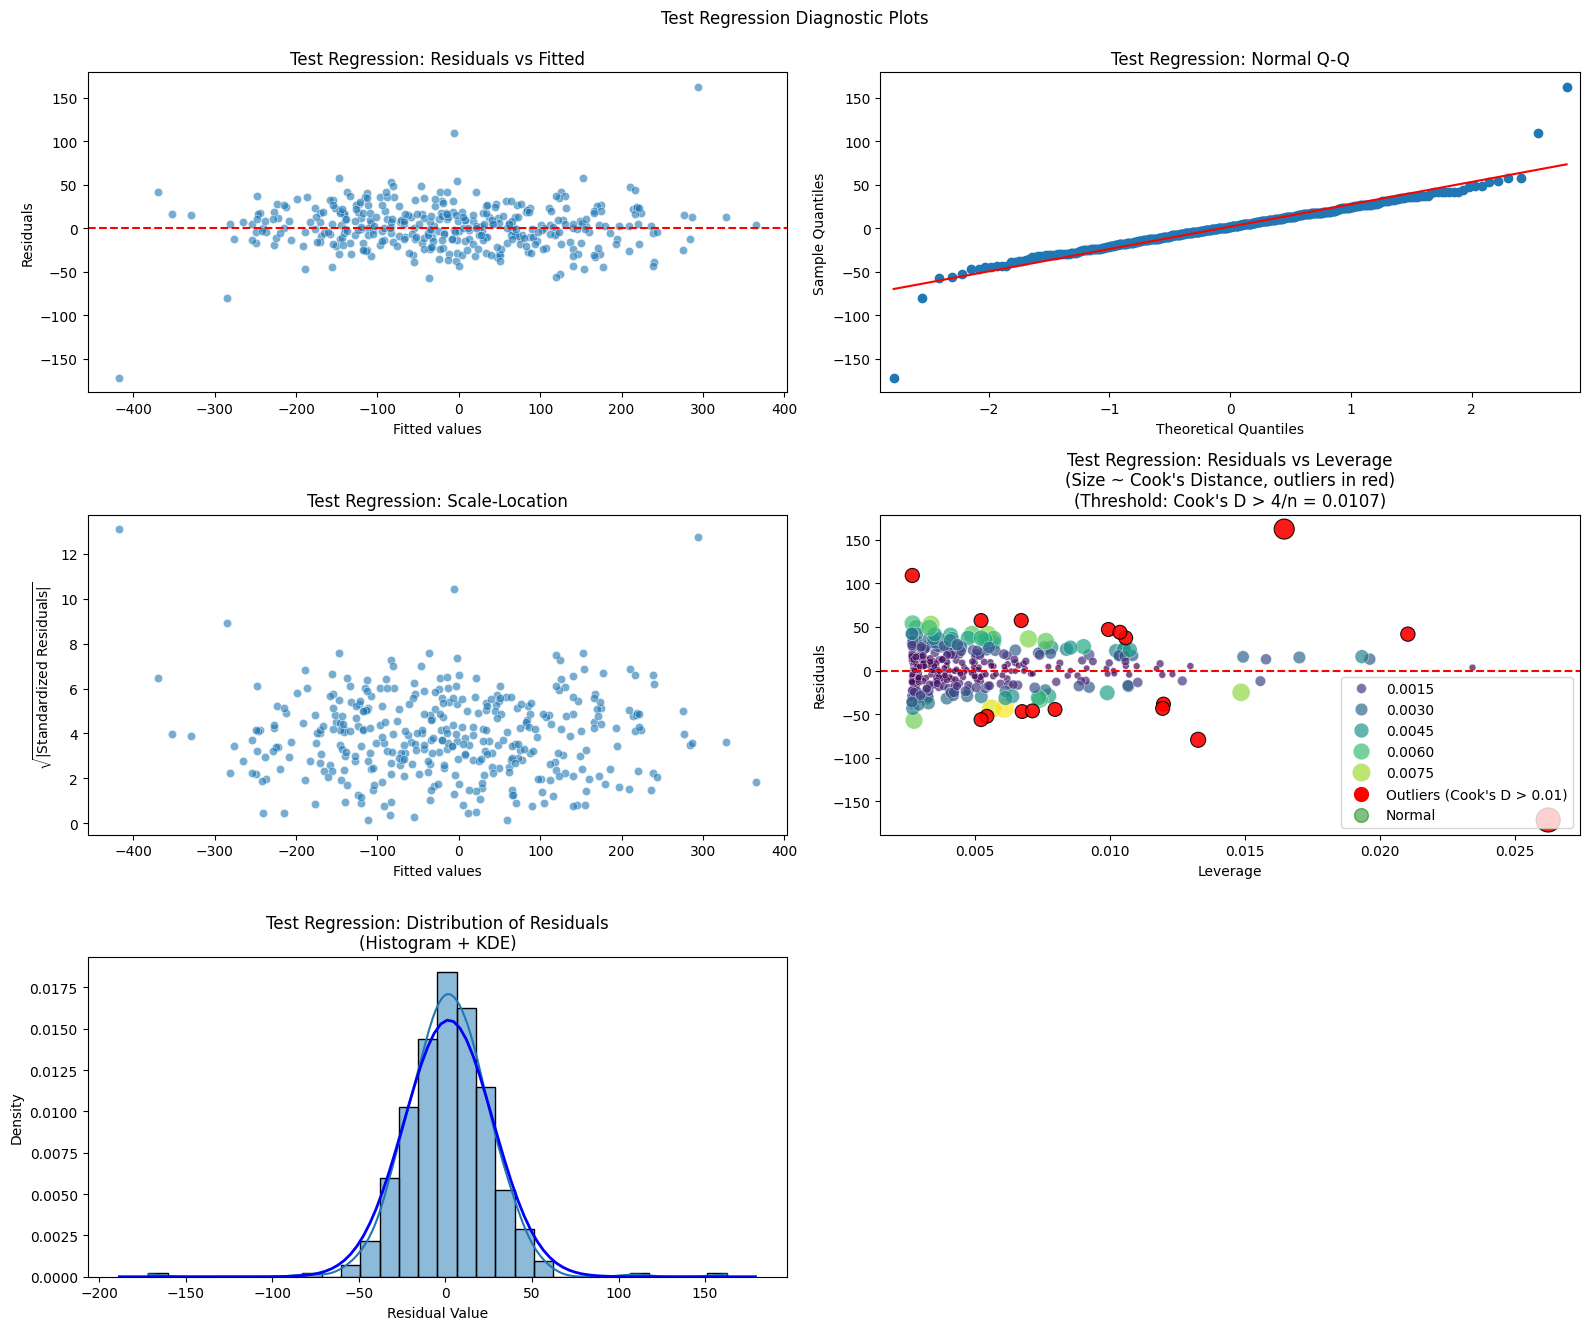


=== Таблица аномальных точек (Cook's D > 0.0107), топ-10 ===
 Index  Leverage    Residual  Cook's D
   318  0.026245 -171.691697  0.614970
   166  0.016461  162.442686  0.338441
   306  0.013271  -79.578725  0.065058
   319  0.021045   41.759222  0.028862
   302  0.002677  109.140797  0.024164
   309  0.011956  -43.484057  0.017454
    98  0.009946   47.130077  0.016988
   368  0.006714   57.424357  0.016913
   116  0.010373   43.900093  0.015385
   272  0.011985  -38.598523  0.013787


,Index,Leverage,Residual,Cook's D
13,318,0.026245,-171.691697,0.614970
6,166,0.016461,162.442686,0.338441
11,306,0.013271,-79.578725,0.065058
14,319,0.021045,41.759222,0.028862
10,302,0.002677,109.140797,0.024164
12,309,0.011956,-43.484057,0.017454
3,98,0.009946,47.130077,0.016988
16,368,0.006714,57.424357,0.016913
4,116,0.010373,43.900093,0.015385
8,272,0.011985,-38.598523,0.013787


In [5]:
pred_test_r = md_reg.model.predict(md_reg.X_test[md_reg.features])
md_reg.diagnostics_plots(md_reg.y_test, pred_test_r, title_prefix="Test Regression")

## Классификация

In [6]:
X_clf, y_clf = make_classification(
    n_samples=1500, n_features=10, n_informative=6, n_redundant=2,
    n_classes=2, random_state=42
)
cols = [f"f{i}" for i in range(X_clf.shape[1])]
X_clf = pd.DataFrame(X_clf, columns=cols)
y_clf = pd.Series(y_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

model_clf = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
model_clf.fit(X_train_c, y_train_c)

md_clf = ModelDiagnostics(
    X_train_c, y_train_c, X_test_c, y_test_c,
    model_clf, task_type="classification"
)

In [ ]:
metrics_train_c, metrics_test_c = md_clf.compute_metrics(print_metrics=True, best_threshold_metric='f1_score')

c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


roc_auc_train: 0.9930848340423379
roc_auc_test: 0.9688246671976334
--------------------------------------------------
pr_auc_train: 0.9933677680108602
pr_auc_test: 0.958432106483253
--------------------------------------------------
ece_train: 0.014051810178568725
ece_test: 0.011297993279781314
--------------------------------------------------
gini_train: 0.9861696680846759
gini_test: 0.9376493343952667
--------------------------------------------------
best_threshold_train: 0.5
best_threshold_test: 0.39
--------------------------------------------------
f1_score_train: 0.9601417183348095
f1_score_test: 0.9198966408268734
--------------------------------------------------
precision_score_train: 0.9575971731448764
precision_score_test: 0.89
--------------------------------------------------
recall_score_train: 0.9626998223801065
recall_score_test: 0.9518716577540107
--------------------------------------------------
sensitivity_train: 0.9626998223801065
sensitivity_test: 0.951871657754

c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


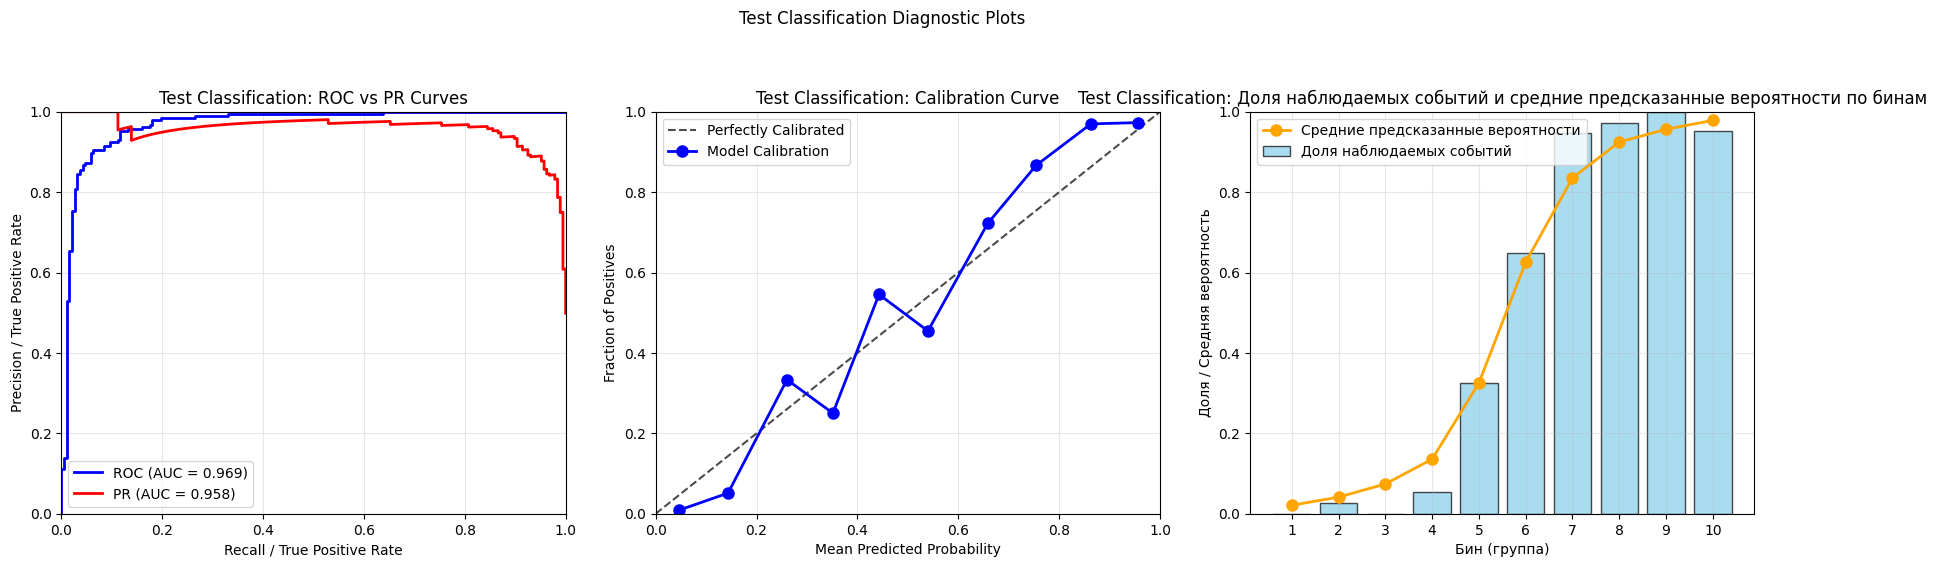

""


In [8]:
pred_proba_c = md_clf.model.predict_proba(md_clf.X_test[md_clf.features])[:, 1]
md_clf.diagnostics_plots(md_clf.y_test, pred_proba_c, title_prefix="Test Classification")

## Полная диагностика (регрессия)

=== Вычисление метрик ===
mse_train: 108.54044899422209
mse_test: 663.3914897002657
--------------------------------------------------
rmse_train: 10.41827476092957
rmse_test: 25.75638735731907
--------------------------------------------------
mae_train: 8.262584738448949
mae_test: 18.591280612247083
--------------------------------------------------
mape_train: 1.2281564831867562
mape_test: 0.805979312137703
--------------------------------------------------
r2_train: 0.9947367983339899
r2_test: 0.9653456352802616
--------------------------------------------------
max_error_train: 42.52946779241179
max_error_test: 171.69169684605242
--------------------------------------------------
bias_train: -0.0015398435249847151
bias_test: 1.8726342284992887
--------------------------------------------------
median_error_train: 0.12427604248973978
median_error_test: 1.4332162009357603
--------------------------------------------------
mpe_train: -0.4565844334780223
mpe_test: 0.07800237374967009


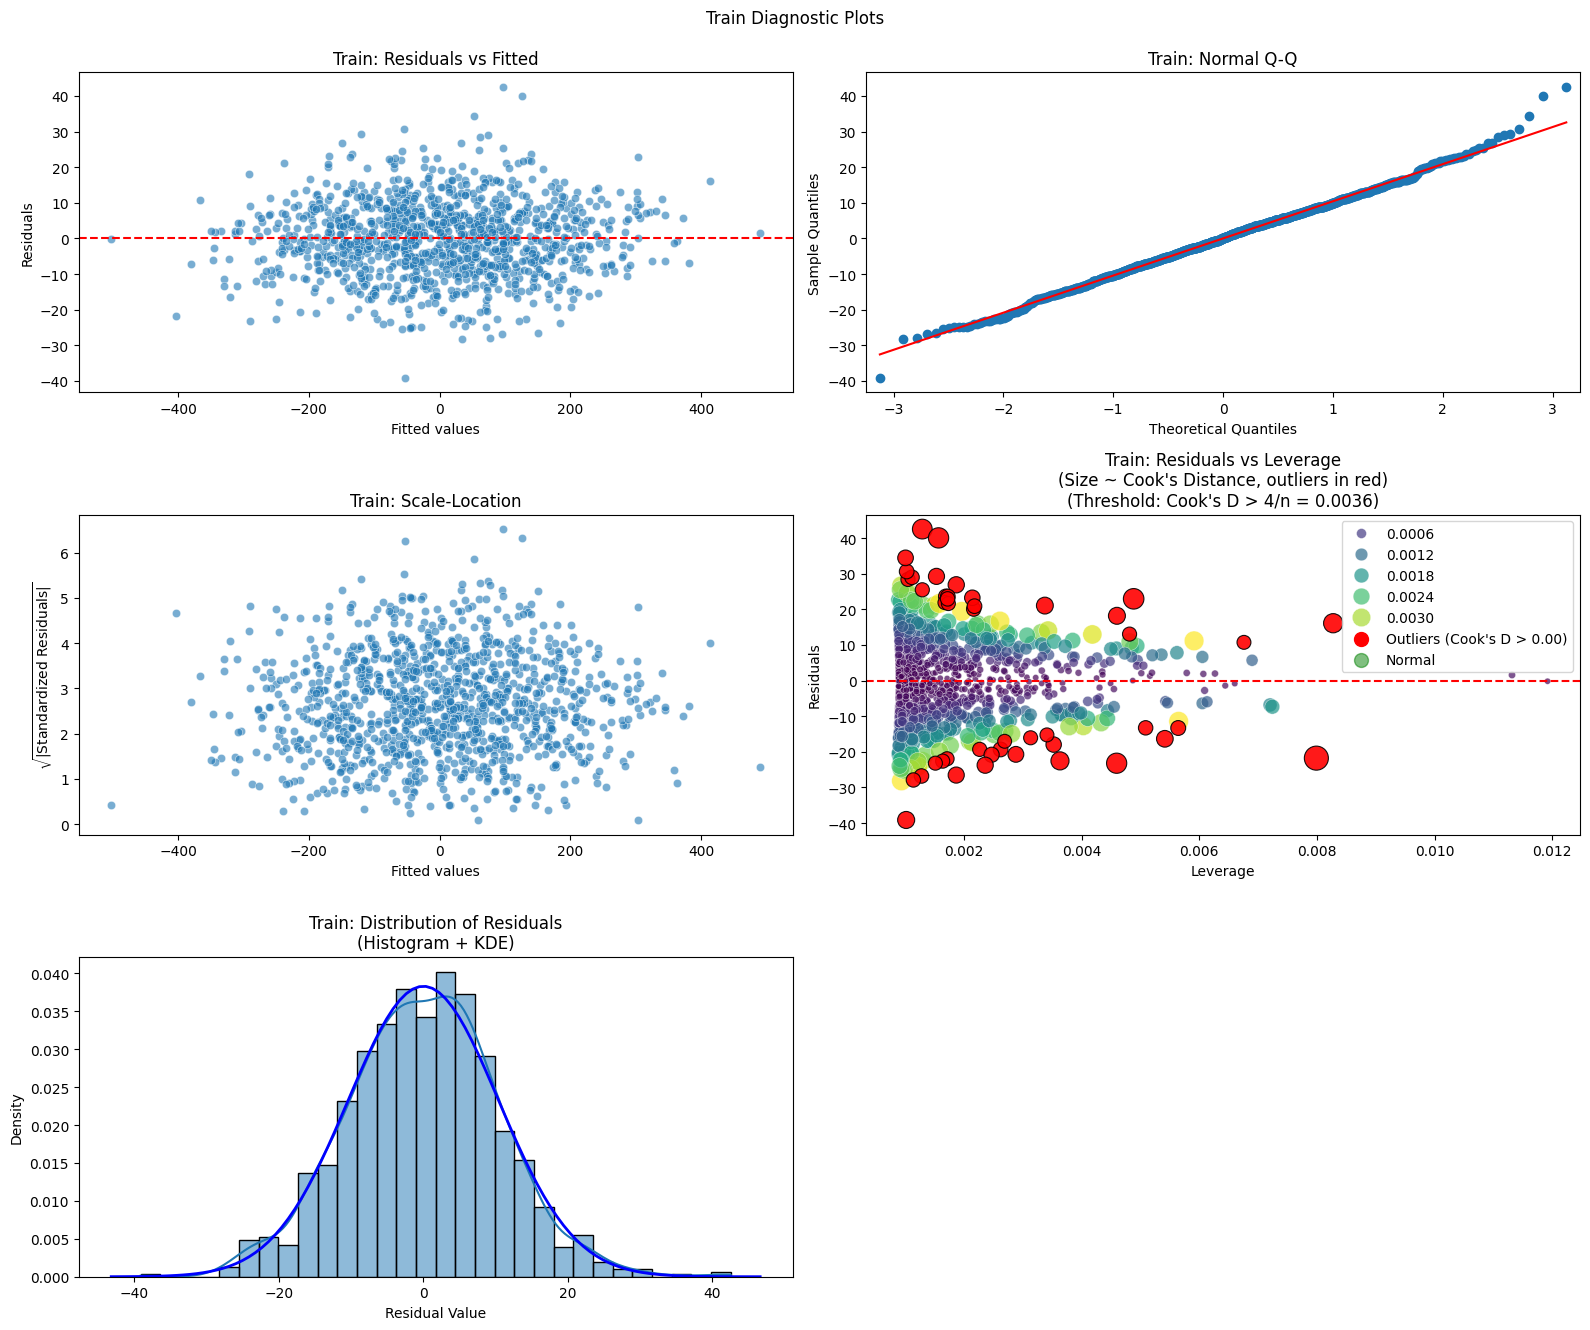


=== Таблица аномальных точек (Cook's D > 0.0036), топ-10 ===
 Index  Leverage   Residual  Cook's D
   813  0.007990 -21.759491  0.017708
  1110  0.004884  22.956259  0.011973
   699  0.001568  40.057146  0.011625
   577  0.004595 -23.186159  0.011485
    94  0.001292  42.529468  0.010791
   363  0.008275  16.107410  0.010056
   742  0.003632 -22.529450  0.008554
   786  0.001017 -39.116053  0.007185
   895  0.004600  18.187790  0.007074
   334  0.003375  21.055048  0.006939


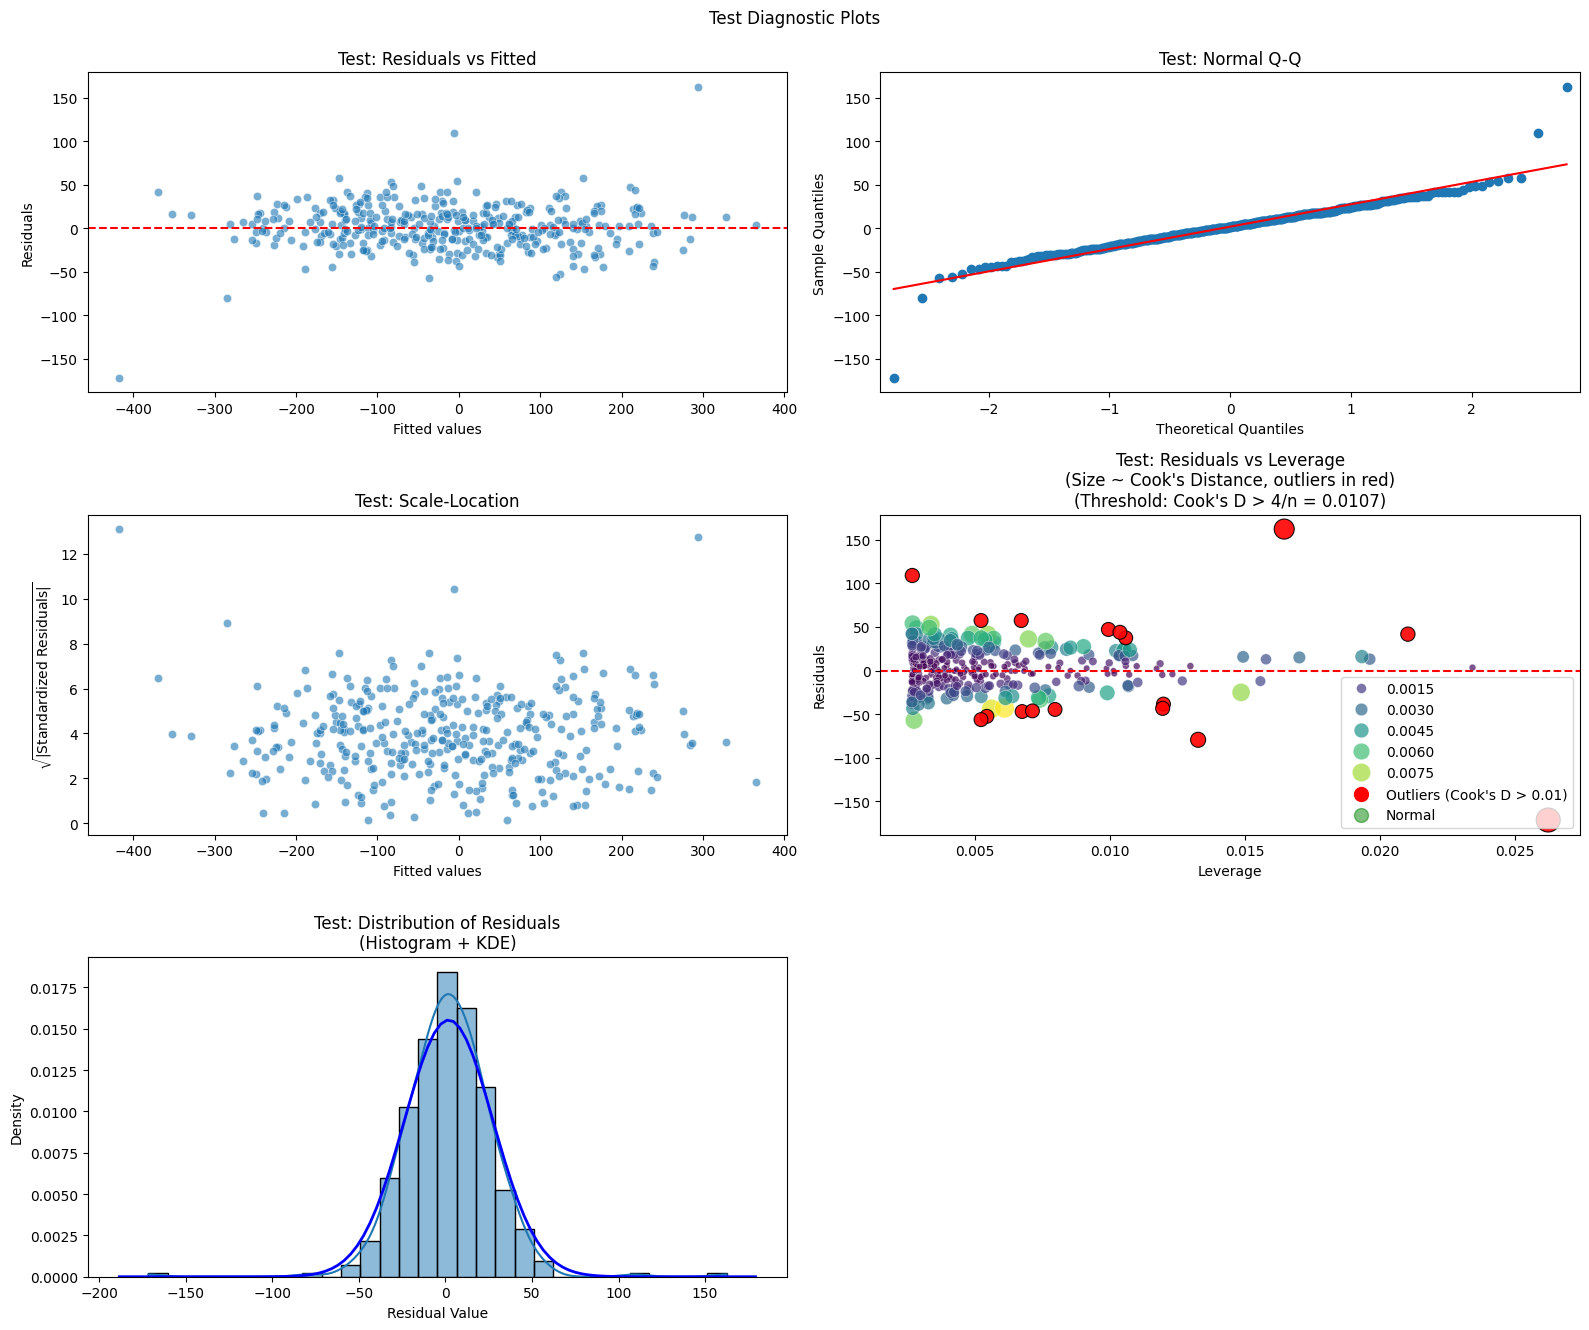


=== Таблица аномальных точек (Cook's D > 0.0107), топ-10 ===
 Index  Leverage    Residual  Cook's D
   318  0.026245 -171.691697  0.614970
   166  0.016461  162.442686  0.338441
   306  0.013271  -79.578725  0.065058
   319  0.021045   41.759222  0.028862
   302  0.002677  109.140797  0.024164
   309  0.011956  -43.484057  0.017454
    98  0.009946   47.130077  0.016988
   368  0.006714   57.424357  0.016913
   116  0.010373   43.900093  0.015385
   272  0.011985  -38.598523  0.013787
=== Тест Колмогорова-Смирнова на нормальность остатков ===
Статистика теста: 0.0480
P-value: 0.3413
Остатки соответствуют нормальному распределению.

=== Тест на гетероскедастичность ===
=== Тесты на гетероскедастичность (разбиение на 5 бинов) ===
Bartlett's test p-value: 0.0000 (Гетероскедастичность)
Levene's test p-value:   0.3027 (Гомоскедастичность)
Fligner-Killeen test p-value: 0.2832 (Гомоскедастичность)
=== Конец тестов ===

=== Adversarial Validation ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.
c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\src\modeldiagnostics.py:578: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(20), x='importance', y='feature', palette='viridis')


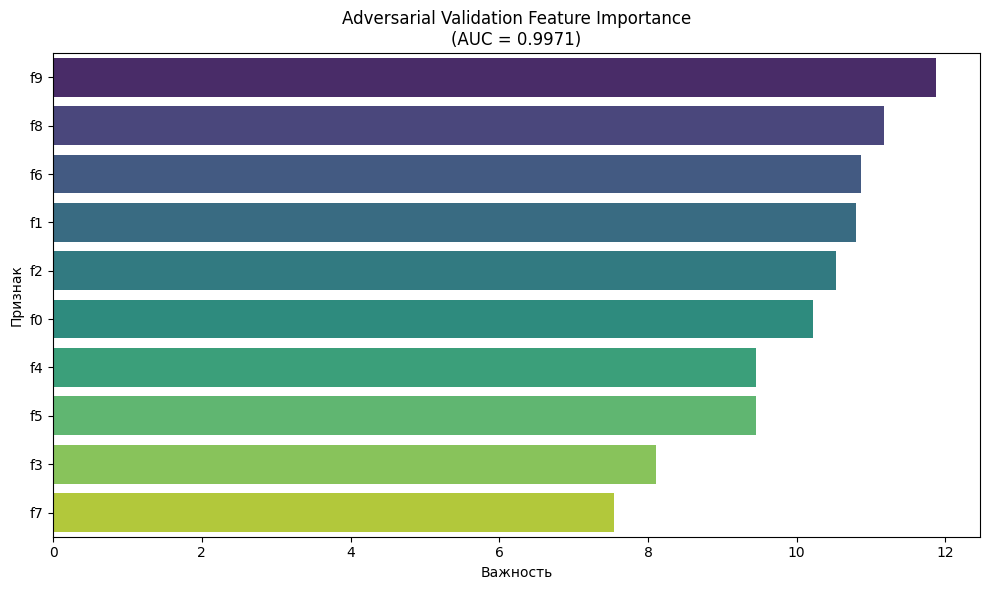

=== Анализ топ-ошибок ===


c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\src\modeldiagnostics.py:653: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(20), x='importance', y='feature', palette='viridis')


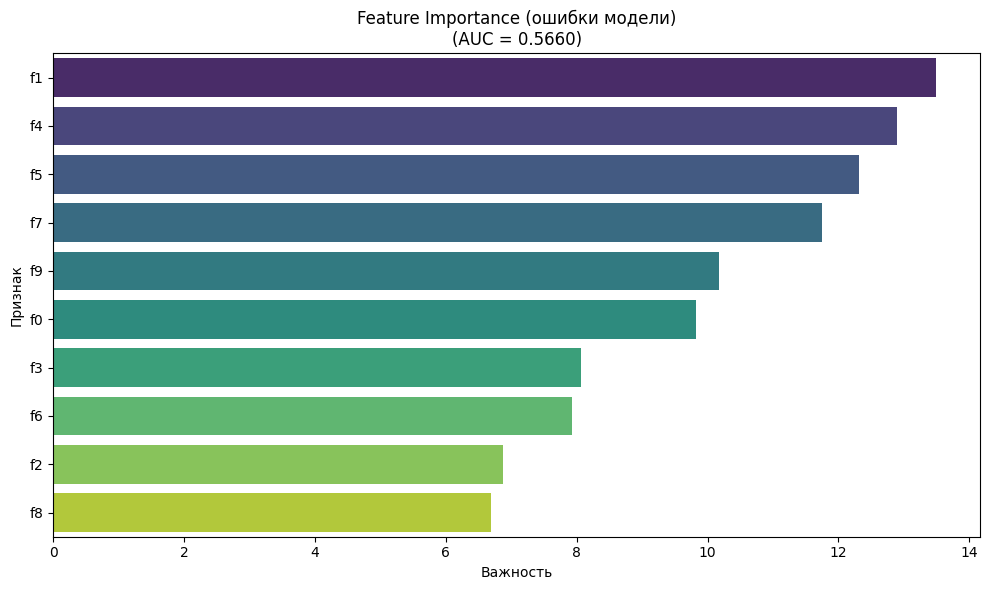

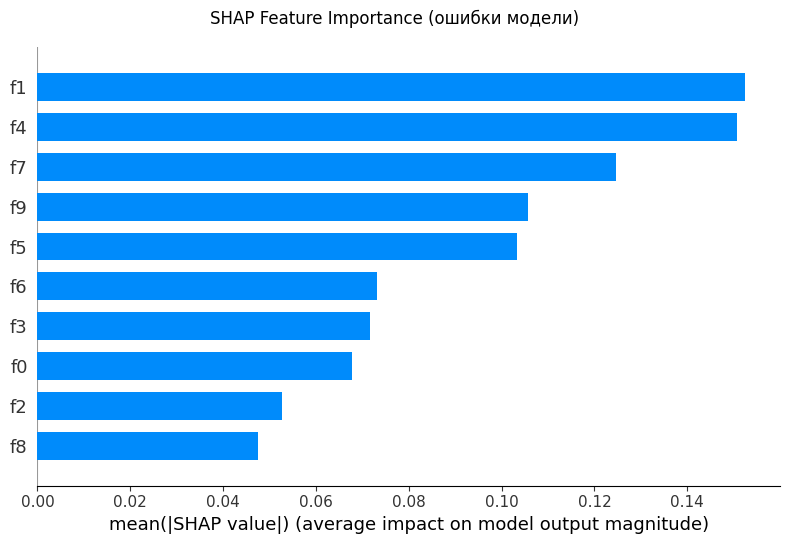

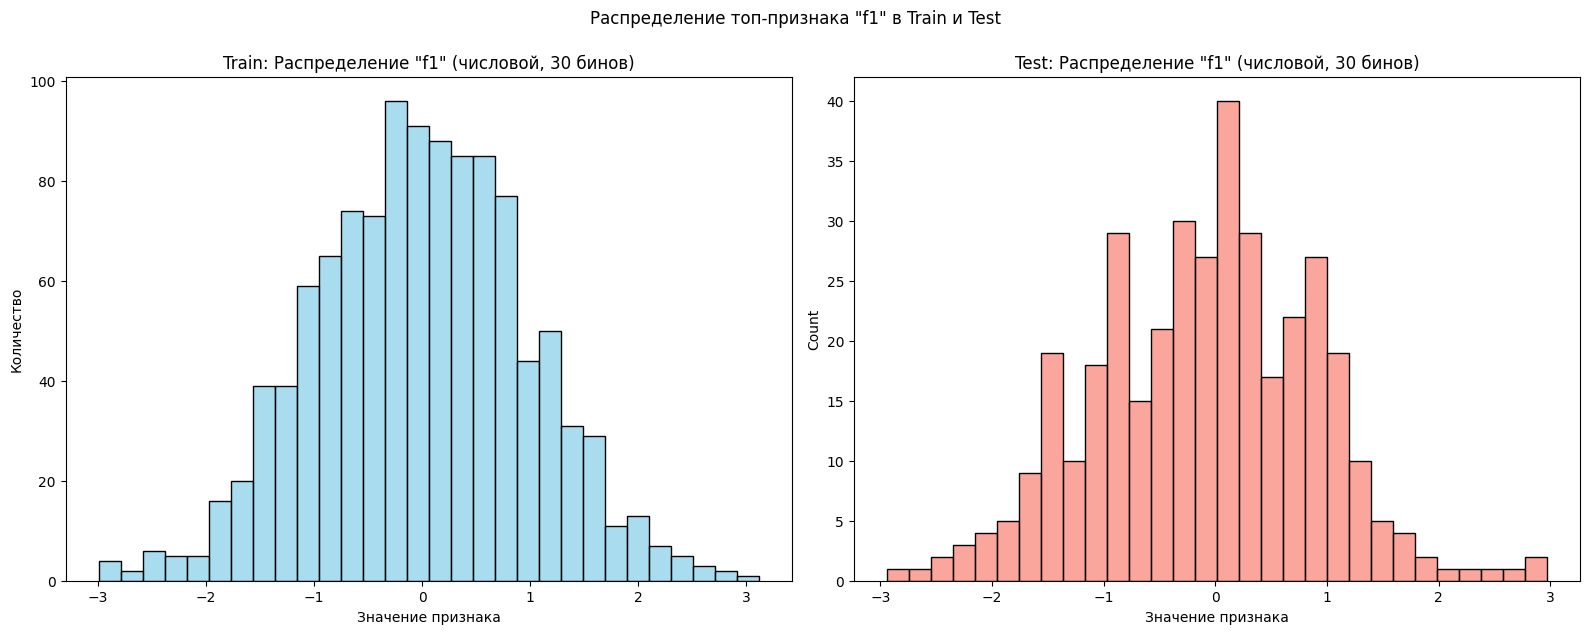

In [9]:
md_reg.run_full_diagnostics()

## Полная диагностика (классификация)

=== Вычисление метрик ===


c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

roc_auc_train: 0.9930848340423379
roc_auc_test: 0.9688246671976334
--------------------------------------------------
pr_auc_train: 0.9933677680108602
pr_auc_test: 0.958432106483253
--------------------------------------------------
ece_train: 0.014051810178568725
ece_test: 0.011297993279781314
--------------------------------------------------
gini_train: 0.9861696680846759
gini_test: 0.9376493343952667
--------------------------------------------------
best_threshold_train: 0.5
best_threshold_test: 0.39
--------------------------------------------------
f1_score_train: 0.9601417183348095
f1_score_test: 0.9198966408268734
--------------------------------------------------
precision_score_train: 0.9575971731448764
precision_score_test: 0.89
--------------------------------------------------
recall_score_train: 0.9626998223801065
recall_score_test: 0.9518716577540107
--------------------------------------------------
sensitivity_train: 0.9626998223801065
sensitivity_test: 0.951871657754

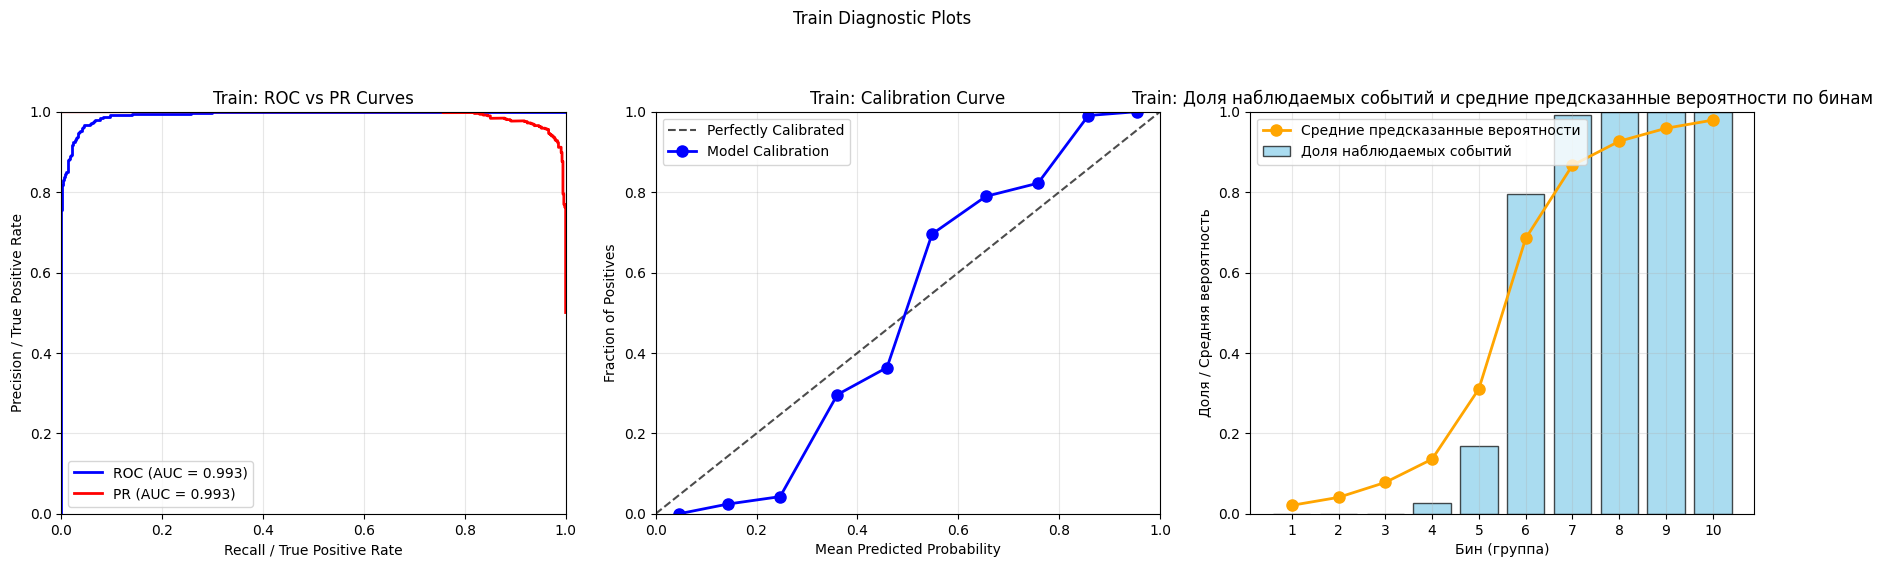

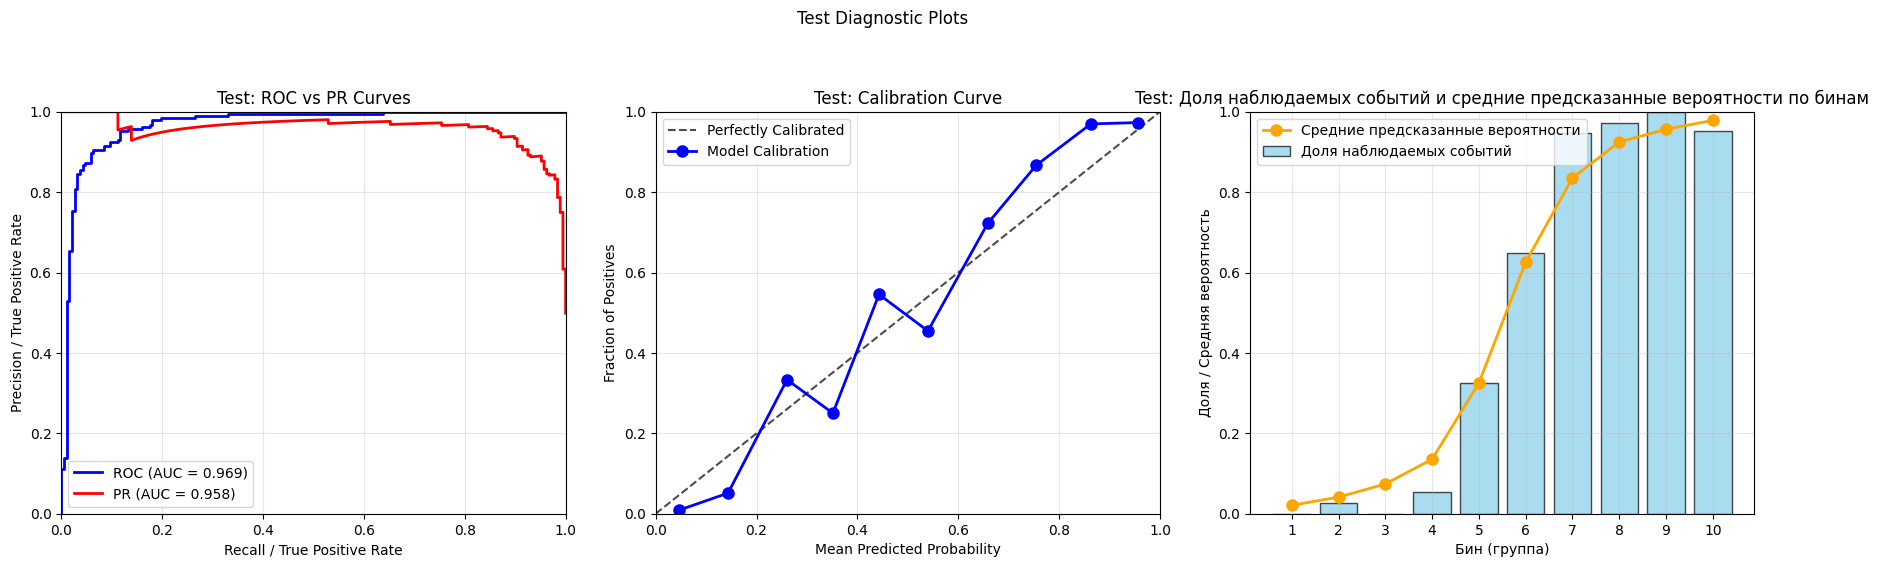

=== Adversarial Validation ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.
c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\src\modeldiagnostics.py:578: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(20), x='importance', y='feature', palette='viridis')


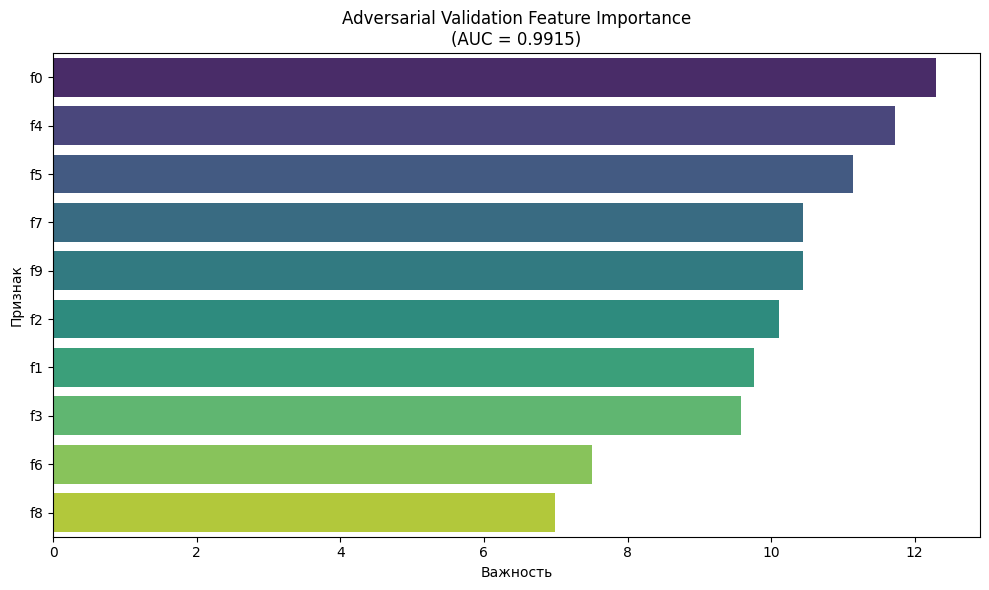

=== Анализ топ-ошибок ===


c:\Users\grchi\Desktop\pet_projects\modeldiagnostics\src\modeldiagnostics.py:653: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.head(20), x='importance', y='feature', palette='viridis')


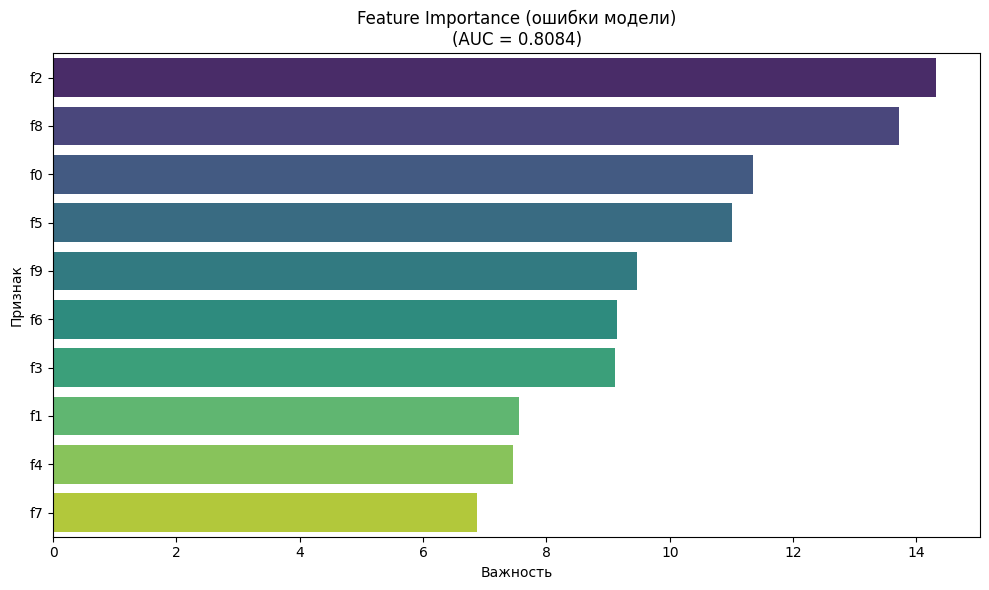

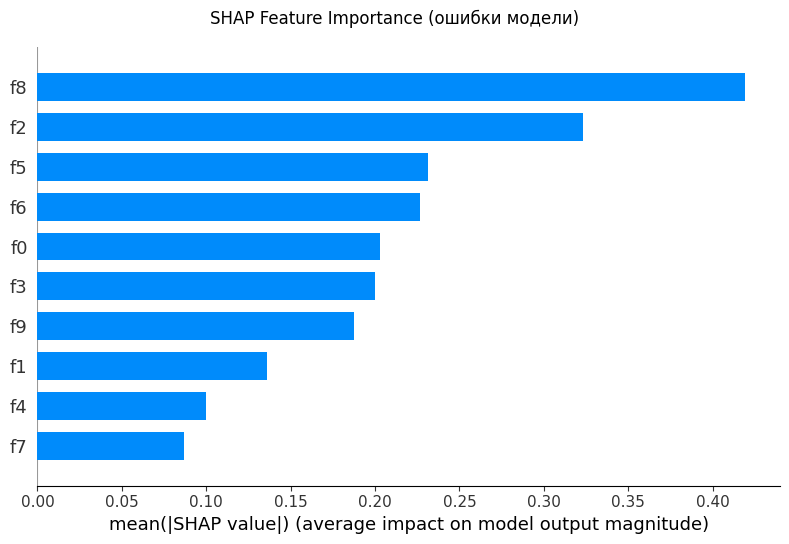

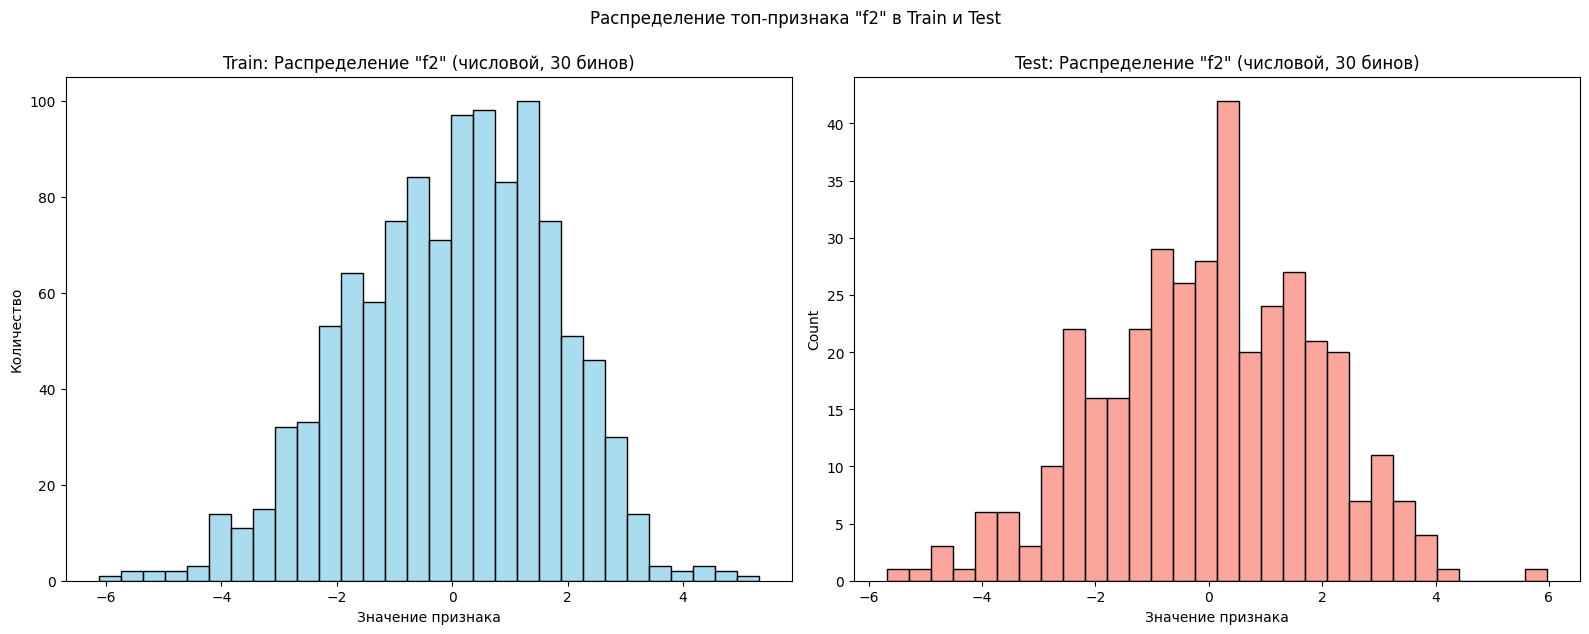

In [10]:
md_clf.run_full_diagnostics()